# Reference design 2 — Two coupled transmons

Two transmons, each with its own multiplexed readout resonator, joined by a meandered coplanar-waveguide coupling bus — the building block of a two-qubit gate.

> **Reference design — attribution.** Adapted, with attribution, from the open-source [SQDMetal](https://github.com/sqdlab/SQDMetal) project (Apache-2.0) and its benchmark devices in D. Sommers, P. Pakkiam, Z. Degnan, C.-C. Chiu, D. Gautam, Y.-H. Chen, and A. Fedorov, *"Open-Source Highly Parallel Electromagnetic Simulations for Superconducting Circuits,"* [arXiv:2511.01220](https://arxiv.org/abs/2511.01220) (2025). Re-implemented here with stock Quantum Metal components.

In [1]:
# In Colab / Binder, uncomment to install Quantum Metal (lite, no Qt):
# !pip install -q quantum-metal

In [2]:
import qiskit_metal as qm
from qiskit_metal import Dict, designs
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal.qlibrary.couplers.coupled_line_tee import CoupledLineTee
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond

design = designs.DesignPlanar()
design.overwrite_enabled = True

06:59PM 27s INFO [_start_renderers]: Renderer=gmsh skipped: runtime dependency not installed (renderer_gmsh requires gmsh. Install with: pip install 'quantum-metal[mesh]' (or the legacy alias 'quantum-metal[fem]')).


In [3]:
def feed(a, ap, b, bp, name):
    """Auto-route a coplanar-waveguide feedline segment between two pins."""
    RoutePathfinder(design, name, options=dict(fillet='90um', pin_inputs=Dict(
        start_pin=Dict(component=a, pin=ap), end_pin=Dict(component=b, pin=bp))))

def readout(clt, q, name, length):
    """Meandered lambda/4 readout resonator: coupled-line tee -> qubit readout pad."""
    RouteMeander(design, name, options=dict(fillet='90um', total_length=length,
        lead=Dict(start_straight='100um', end_straight='100um'),
        pin_inputs=Dict(start_pin=Dict(component=clt, pin='second_end'),
                        end_pin=Dict(component=q, pin='readout'))))

## 1. Two transmons

Each transmon gets a `readout` pad (top, outward) and a `coupler` pad (bottom, facing its neighbour).

In [4]:
TransmonPocket(design,'Q1',options=dict(pos_x='-2.5mm',pos_y='-1.5mm',pad_width='425um',pocket_height='650um',
    connection_pads=dict(readout=dict(loc_W=-1,loc_H=1), coupler=dict(loc_W=1,loc_H=-1))))
TransmonPocket(design,'Q2',options=dict(pos_x='2.5mm',pos_y='-1.5mm',pad_width='425um',pocket_height='650um',
    connection_pads=dict(readout=dict(loc_W=1,loc_H=1), coupler=dict(loc_W=-1,loc_H=-1))))

name:    Q2
class:   TransmonPocket        
options: 
  'pos_x'             : '2.5mm',                      
  'pos_y'             : '-1.5mm',                     
  'orientation'       : '0.0',                        
  'chip'              : 'main',                       
  'layer'             : '1',                          
  'connection_pads'   : {
       'readout'           : {
            'pad_gap'           : '15um',                       
            'pad_width'         : '125um',                      
            'pad_height'        : '30um',                       
            'pad_cpw_shift'     : '5um',                        
            'pad_cpw_extent'    : '25um',                       
            'cpw_width'         : 'cpw_width',                  
            'cpw_gap'           : 'cpw_gap',                    
            'cpw_extend'        : '100um',                      
            'pocket_extent'     : '5um',                        
            'pocket_rise'    

## 2. Shared feedline + two readout resonators

One feedline, two coupled-line tees, two resonators of slightly different length (frequency-multiplexed readout).

In [5]:
CoupledLineTee(design,'clt1',options=dict(pos_x='-2.5mm',pos_y='1.5mm',coupling_length='350um',down_length='300um',fillet='90um',open_termination=False))
CoupledLineTee(design,'clt2',options=dict(pos_x='2.5mm',pos_y='1.5mm',coupling_length='350um',down_length='300um',fillet='90um',open_termination=False))
LaunchpadWirebond(design,'LP1',options=dict(pos_x='-6mm',pos_y='1.5mm',orientation='0'))
LaunchpadWirebond(design,'LP2',options=dict(pos_x='6mm',pos_y='1.5mm',orientation='180'))
feed('LP1','tie','clt1','prime_start','feed_L')
feed('clt1','prime_end','clt2','prime_start','feed_M')
feed('clt2','prime_end','LP2','tie','feed_R')
readout('clt1','Q1','read1','7.0mm')
readout('clt2','Q2','read2','7.2mm')

## 3. Qubit-qubit coupling bus

A meandered CPW between the two `coupler` pads sets the exchange coupling.

In [6]:
RouteMeander(design,'coupler_bus',options=dict(fillet='90um',total_length='8mm',
    lead=Dict(start_straight='150um',end_straight='150um'),meander=Dict(asymmetry='200um'),
    pin_inputs=Dict(start_pin=Dict(component='Q1',pin='coupler'),end_pin=Dict(component='Q2',pin='coupler'))))

06:59PM 27s WARNING [check_lengths]: For path table, component=coupler_bus, key=trace has short segments that could cause issues with fillet. Values in (37-38)  are index(es) in shapely geometry.


06:59PM 27s WARNING [check_lengths]: For path table, component=coupler_bus, key=cut has short segments that could cause issues with fillet. Values in (37-38)  are index(es) in shapely geometry.


name:    coupler_bus
class:   RouteMeander          
options: 
  'chip'              : 'main',                       
  'layer'             : '1',                          
  'pin_inputs'        : {
       'start_pin'         : {
            'component'         : 'Q1',                         
            'pin'               : 'coupler',                    
                             },
       'end_pin'           : {
            'component'         : 'Q2',                         
            'pin'               : 'coupler',                    
                             },
                        },
  'fillet'            : '90um',                       
  'lead'              : {
       'start_straight'    : '150um',                      
       'end_straight'      : '150um',                      
       'start_jogged_extension': '',                           
       'end_jogged_extension': '',                           
                        },
  'total_length'      : '8mm',    

## 4. Visualize

## Next steps

- **Inspect** the design tree: `design.components.keys()` and `design.qgeometry.tables`.
- **Export GDS** for fabrication: `design.renderers.gds.export_to_gds('chip.gds')` (Quantum Metal uses the modern `gdstk` backend).
- **Simulate**: render to Ansys HFSS/Q3D (the validation gold standard) or to the open-source FEM path (Gmsh + Elmer today; AWS Palace on the roadmap) to extract eigenmodes, *Q*, and the capacitance matrix.
- **Tweak**: every dimension above is a parameter — change `total_length` to retune resonator frequencies, or `pos_x`/`pos_y` to relayout.

In [7]:
design.components.keys()

['Q1',
 'Q2',
 'clt1',
 'clt2',
 'LP1',
 'LP2',
 'feed_L',
 'feed_M',
 'feed_R',
 'read1',
 'read2',
 'coupler_bus']

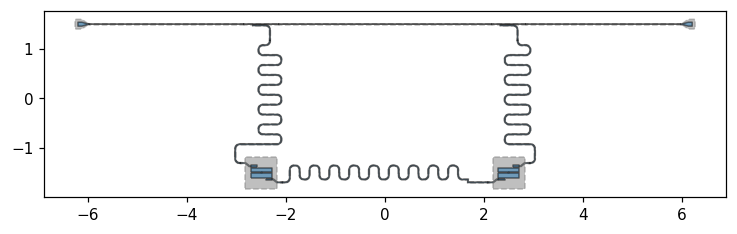

In [8]:
fig = qm.view(design)
try:
    qm.show_inline(fig)
except Exception:
    from IPython.display import display; display(fig)